<a href="https://colab.research.google.com/github/sissi820li/APS360/blob/main/MisinformationDetectionProject/MisinformationDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Changes made to final MisinfoLSTM architecture that is different from the prototype:

1. Learning rate: Change from 0.01 to 0.001. The Adam optimizer usually performs better with a lower rate, usually around 0.001 or 0.005. A high learning rate caused the prototype model to overshoot optimal weights so for the final model, the learning rate is lowered.

2. Add a 0.2 dropout & dropout layer: This will prevent the neural network to focus on a specific word or phrase that appears frequently in the "fake" category when training. The model will be forced to drop 20% of neurons during each forward pass, preventing it from focusing on one "trigger" neuron. This will force it to look at broader sentence context, distribute its learning, and only learn the most meaningful patterns.

3. Add Weight Decay or L2 Regularization: Prevent the model from becoming too "confident" and connecting larger weights to certian vocab words as it trains. This will keep this weights small and ensure the model does not create rigid rules that will fail on new data. 

Before adding these changes, the prototype model had a problem with overfitting and memorizing data and key words, resulting in poor performance with validation data and an accuracy of 78.22%.

In [10]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [3]:
class MisinfoLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim=1, n_layers=1, bidirectional=True):
        super().__init__()
        self.name = "MisinfoLSTM"
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        self.lstm = nn.LSTM(embedding_dim, 
                            hidden_dim, 
                            num_layers=n_layers, 
                            bidirectional=bidirectional, 
                            batch_first=True,
                            dropout=0.2) # Add a dropout
        
        linear_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
  
        self.dropout = nn.Dropout(0.2) # Add a dropout layer
        
        self.fc = nn.Linear(linear_input_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, text):
        embedded = self.embedding(text)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        if self.lstm.bidirectional:
            hidden_final = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden_final = hidden[-1,:,:]

        dropped_out = self.dropout(hidden_final) # Pass final hidden state through dropout layer
        dense_outputs = self.fc(dropped_out) # Pass dropped out tensor into fully connected layer
        
        return self.sigmoid(dense_outputs).squeeze()

def get_model_name(name, batch_size, learning_rate, epoch):
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

Helper Functions and Training

In [4]:
def evaluate(net, loader, criterion):
    total_loss = 0.0
    total_err = 0.0
    total_epoch = 0
    
    with torch.no_grad():
        for i, data in enumerate(loader, 0):
            inputs, labels = data
            
            labels = labels.float() 
            
            outputs = net(inputs)
            loss = criterion(outputs, labels)

            predicted = torch.round(outputs)
            
            corr = predicted != labels
            total_err += int(corr.sum())
            total_loss += loss.item()
            total_epoch += len(labels)
            
    err = float(total_err) / total_epoch
    loss = float(total_loss) / (i + 1)
    return err, loss

def train_net(net, train_loader, val_loader, batch_size=32, learning_rate=0.001, num_epochs=10):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(net.parameters(), lr=learning_rate, weight_decay=1e-4) # Add weight decay to Adam Optimizer

    train_err = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    val_err = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)

    start_time = time.time()
    for epoch in range(num_epochs): 
        total_train_loss = 0.0
        total_train_err = 0.0
        total_epoch = 0
        
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data
            
            # Convert labels to float
            labels = labels.float()
            
            optimizer.zero_grad()
            
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            # Calculate the statistics using rounding for binary outputs
            predicted = torch.round(outputs)
            corr = predicted != labels
            total_train_err += int(corr.sum())
            total_train_loss += loss.item()
            total_epoch += len(labels)
            
        train_err[epoch] = float(total_train_err) / total_epoch
        train_loss[epoch] = float(total_train_loss) / (i+1)
        
        # Evaluate on the validation set
        val_err[epoch], val_loss[epoch] = evaluate(net, val_loader, criterion)
        
        print(("Epoch {}: Train err: {:.4f}, Train loss: {:.4f} | "+
               "Validation err: {:.4f}, Validation loss: {:.4f}").format(
                   epoch + 1,
                   train_err[epoch],
                   train_loss[epoch],
                   val_err[epoch],
                   val_loss[epoch]))
        
        # Save current model to a file
        model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
        torch.save(net.state_dict(), model_path)
        
    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    
    np.savetxt("{}_train_err.csv".format(model_path), train_err)
    np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
    np.savetxt("{}_val_err.csv".format(model_path), val_err)
    np.savetxt("{}_val_loss.csv".format(model_path), val_loss)
    
    return model_path

In [5]:
def plot_training_curve(path):
    """ Plots the training curve for a model run, given the csv files
    containing the train/validation error/loss.

    Args:
        path: The base path of the csv files produced during training
    """
    import matplotlib.pyplot as plt
    train_err = np.loadtxt("{}_train_err.csv".format(path))
    val_err = np.loadtxt("{}_val_err.csv".format(path))
    train_loss = np.loadtxt("{}_train_loss.csv".format(path))
    val_loss = np.loadtxt("{}_val_loss.csv".format(path))
    plt.title("Train vs Validation Error")
    n = len(train_err) # number of epochs
    plt.plot(range(1,n+1), train_err, label="Train")
    plt.plot(range(1,n+1), val_err, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend(loc='best')
    plt.show()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), train_loss, label="Train")
    plt.plot(range(1,n+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

Train and Evaluate the model

Epoch 1: Train err: 0.4220, Train loss: 0.6755 | Validation err: 0.3480, Validation loss: 0.6248
Epoch 2: Train err: 0.2796, Train loss: 0.5473 | Validation err: 0.2683, Validation loss: 0.5291
Epoch 3: Train err: 0.1758, Train loss: 0.4174 | Validation err: 0.2379, Validation loss: 0.4981
Epoch 4: Train err: 0.1213, Train loss: 0.3072 | Validation err: 0.2317, Validation loss: 0.5675
Epoch 5: Train err: 0.0802, Train loss: 0.2132 | Validation err: 0.2369, Validation loss: 0.5754
Epoch 6: Train err: 0.0438, Train loss: 0.1390 | Validation err: 0.2212, Validation loss: 0.7119
Epoch 7: Train err: 0.0366, Train loss: 0.1119 | Validation err: 0.2201, Validation loss: 0.7078
Epoch 8: Train err: 0.0258, Train loss: 0.0853 | Validation err: 0.2379, Validation loss: 0.7824
Epoch 9: Train err: 0.0225, Train loss: 0.0723 | Validation err: 0.2243, Validation loss: 0.8404
Epoch 10: Train err: 0.0186, Train loss: 0.0655 | Validation err: 0.2285, Validation loss: 0.8409
Epoch 11: Train err: 0.0175, 

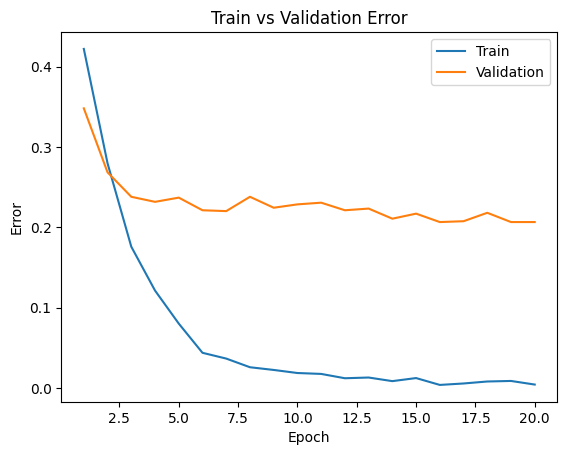

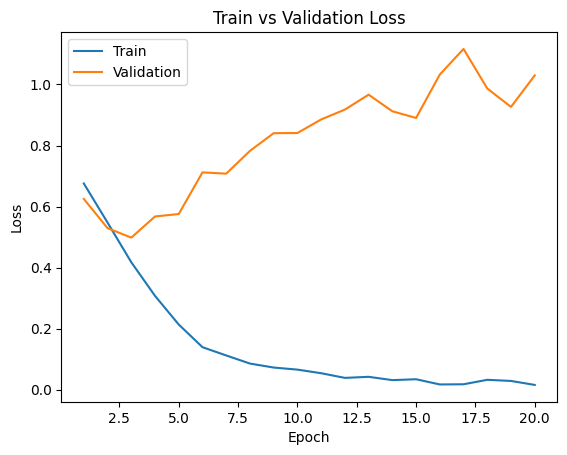

In [ ]:
# Load the data
loaded_train = torch.load('dataset/dataset_tensors/dataset_split/train_tensors.pt')
train_dataset = TensorDataset(loaded_train['features'], loaded_train['labels'])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

loaded_val = torch.load('dataset/dataset_tensors/dataset_split/val_tensors.pt')
val_dataset = TensorDataset(loaded_val['features'], loaded_val['labels'])
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Initialize model
# Find highest token ID in training and validation tensors
max_train_id = loaded_train['features'].max().item()
max_val_id = loaded_val['features'].max().item()

# The vocab size must be greater than highest token ID
VOCAB_SIZE = max(max_train_id, max_val_id) + 1 
EMBEDDING_DIM = 100
HIDDEN_DIM = 32

misinfo = MisinfoLSTM(vocab_size=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM, hidden_dim=HIDDEN_DIM, n_layers=1, bidirectional=True)

# Train and plot
model_path = train_net(misinfo, train_loader=train_loader, val_loader=val_loader, batch_size=32, learning_rate=0.001, num_epochs=20)
plot_training_curve(model_path)

Test the final model

In [7]:
criterion = nn.BCELoss()

# Load the data
loaded_test = torch.load('dataset/dataset_tensors/dataset_split/test_tensors.pt')
test_dataset = TensorDataset(loaded_test['features'], loaded_test['labels'])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

test_err, test_loss = evaluate(misinfo, test_loader, criterion)
test_accuracy = 1.0 - test_err

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

Final Test Accuracy: 76.23%
Final Test Loss: 0.6217


Test the final model with newly collected data

In [8]:
# Load the data
loaded_final_test = torch.load('dataset/dataset_tensors/dataset_split/final_test_tensors.pt')
final_test_dataset = TensorDataset(loaded_final_test['features'], loaded_final_test['labels'])
final_test_loader = DataLoader(final_test_dataset, batch_size=32, shuffle=True)

test_err, test_loss = evaluate(misinfo, final_test_loader, criterion)
test_accuracy = 1.0 - test_err

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

Final Test Accuracy: 48.40%
Final Test Loss: 1.4922
